In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import heapq
import seaborn as sns

from environment.environment import GraphWorldMFG_MultiGroup
from trainer.amid_trainer_graph import GraphEdgeMFG_Trainer
from solver.solver import solve_multigroup, GraphMFG_OMD_EdgeSolver_MultiGroup
from visualization.visualizationh import plot_heatmap, compute_exploitability_multigroup, plot_losses, plot_losses_line

In [2]:
import os
from pathlib import Path
import yaml
import numpy as np
import torch

# 1. Configuration Loader
def load_config(config_path="config.yaml"):
    """Load configuration safely from a YAML file relative to working directory."""
    notebook_dir = Path(os.getcwd())
    config_file = notebook_dir / config_path
    
    with open(config_file, 'r') as f:
        config = yaml.safe_load(f)
    return config

# 2. Graph Environment Factory Pattern
def create_graph_mfg_from_config(config):
    """Factory function initializing the Graph MFG environment directly from your config."""
    device = config.get("device", "cuda" if torch.cuda.is_available() else "cpu")
    print(f"Target Device: {device}")

    trainer_cfg = config["trainer"]
    
    # Extract Graph Configuration
    graph_cfg = config["graph"]
    num_nodes = graph_cfg["num_nodes"]
    
    # CRITICAL: Extract the list of lists matrix and convert to a PyTorch Tensor
    raw_matrix = graph_cfg["adjacency_matrix"]
    adjacency_matrix = torch.tensor(raw_matrix, dtype=torch.float32, device=device)
    
    # Process Group Data (Sinks and Sources are flat integers here, not grid tuples)
    groups = []
    for g in config["groups"]:
        groups.append({
            "source": int(g["source"]),
            "sink": int(g["sink"]),
            "mass": float(g["mass"])
        })
    
    solver_cfg = config["solver"]
    waiting_time = solver_cfg.get("waiting_time", 0)
    # Instantiate the Graph World Environment
    # (Matches your 'GraphWorldMFG_MultiGroup' class structure)
    env = GraphWorldMFG_MultiGroup(
        num_nodes=num_nodes,
        groups=groups,
        adjacency_matrix=adjacency_matrix,
        H = solver_cfg.get("H", None),
        device=device
    )
    
    # Create solvers for each group
    
    
    solvers = [
        GraphMFG_OMD_EdgeSolver_MultiGroup(
            env=env,
            group_idx=k,
            eta=solver_cfg["eta"],
            tau=solver_cfg["tau"],
            T=solver_cfg["T"],
            alpha=solver_cfg["alpha"],
            H=solver_cfg.get("H", None)
        )
        for k in range(env.K)
    ]

    trainer = GraphEdgeMFG_Trainer(env, solvers, leader_lr=trainer_cfg["leader_lr"])
    
    return env, solvers, trainer, config

In [3]:
config = load_config("config_graph.yaml")

env, solvers, trainer, config = create_graph_mfg_from_config(config)

# Training loop
theta_leader = torch.zeros((env.N, env.N), device=env.device)  # Initialize leader's strategy
#theta_leader[1,2] = 5.0
#theta_leader[2,1] = 5.0

Target Device: cpu


c:\Uzh\thesis\msc_code\thesis\environment\environment.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.A = torch.tensor(adjacency_matrix, dtype=torch.float32, device=device)


In [4]:
env.A.sum()

tensor(76.)

In [5]:
edge_cost = torch.zeros((env.N, env.N), device=env.device)
edge_cost[0, 1] = 6
edge_cost[0, 2] = 4
edge_cost[1, 0] = 6
edge_cost[1, 5] = 5
edge_cost[2, 0] = 4

edge_cost[2, 3] = 4
edge_cost[2, 11] = 4
edge_cost[3, 2] = 4
edge_cost[3, 4] = 2
edge_cost[3, 10] = 6

edge_cost[4, 3] = 2
edge_cost[4, 5] = 4
edge_cost[4, 8] = 5
edge_cost[5, 1] = 5
edge_cost[5, 4] = 4

edge_cost[5, 7] = 2
edge_cost[6, 7] = 3
edge_cost[6, 17] = 2
edge_cost[7, 5] = 2
edge_cost[7, 6] = 3

edge_cost[7, 8] = 10
edge_cost[7, 15] = 5
edge_cost[8, 4] = 5
edge_cost[8, 7] = 10
edge_cost[8, 9] = 3

edge_cost[9, 8] = 3
edge_cost[9, 10] = 5
edge_cost[9, 14] = 6
edge_cost[9, 15] = 4
edge_cost[9, 16] = 8

edge_cost[10, 3] = 6
edge_cost[10, 9] = 5
edge_cost[10, 11] = 6
edge_cost[10, 13] = 4
edge_cost[11, 2] = 4

edge_cost[11, 10] = 6
edge_cost[11, 12] = 3
edge_cost[12, 11] = 3
edge_cost[12, 23] = 4
edge_cost[13, 10] = 4

edge_cost[13, 14] = 5
edge_cost[13, 22] = 4
edge_cost[14, 9] = 6
edge_cost[14, 13] = 5
edge_cost[14, 18] = 3

edge_cost[14, 21] = 3
edge_cost[15, 7] = 5
edge_cost[15, 9] = 4
edge_cost[15, 16] = 2
edge_cost[15, 17] = 3

edge_cost[16, 9] = 8
edge_cost[16, 15] = 2
edge_cost[16, 18] = 2
edge_cost[17, 6] = 2
edge_cost[17, 15] = 3

edge_cost[17, 19] = 4
edge_cost[18, 14] = 3
edge_cost[18, 16] = 2
edge_cost[18, 19] = 4
edge_cost[19, 17] = 4

edge_cost[19, 18] = 4
edge_cost[19, 20] = 6
edge_cost[19, 21] = 5
edge_cost[20, 19] = 6
edge_cost[20, 21] = 2

edge_cost[20, 23] = 3
edge_cost[21, 14] = 3
edge_cost[21, 19] = 5
edge_cost[21, 20] = 2
edge_cost[21, 22] = 4

edge_cost[22, 13] = 4
edge_cost[22, 21] = 4
edge_cost[22, 23] = 2
edge_cost[23, 12] = 4
edge_cost[23, 20] = 3

edge_cost[23, 22] = 2
edge_cost -= 2
edge_cost.clamp_(min=0.0, max=10.0)

trainer.edge_cost = edge_cost

In [18]:
node_mass, edge_occ, final_flows, policies, W_cong_history, zeta_history = solve_multigroup(
    env, solvers, T=10, W_max=100, theta_leader=theta_leader,
    edge_cost=edge_cost, congest_all_edges=True
)

In [19]:
exploitability, V_best, V_pi = solvers[0].compute_exploitability(W_cong_history, W_max=100, theta_leader=theta_leader)
exploitability

0.10419464111328125

In [ ]:
a = trainer.compute_social_loss(final_flows, W_cong_history)
a

tensor(25.5401)

In [ ]:
import os
import numpy as np
import torch
import networkx as nx
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- 1. Extract environment variables from your notebook execution ---
num_nodes = env.num_nodes
nodes = [str(i) for i in range(num_nodes)]

# Pull physical roads defined in your environment's adjacency matrix
adjacency_matrix = env.A.cpu().numpy()
road_topology = []
for u_idx in range(num_nodes):
    for v_idx in range(num_nodes):
        if adjacency_matrix[u_idx, v_idx] > 0:
            road_topology.append((str(u_idx), str(v_idx)))

# --- 2. Node coordinates: works for ANY num_nodes, not just the original 4-node setup ---
# Tries to load the real, published Sioux Falls layout if you have the file locally;
# otherwise falls back to an automatic, deterministic graph layout via networkx.
node_coords = None
tntp_path = "SiouxFalls_node.tntp"  # adjust path if you've downloaded this file
if os.path.exists(tntp_path):
    node_coords = {}
    with open(tntp_path) as f:
        next(f)  # skip header line
        for line in f:
            line = line.strip().strip(';')
            if not line:
                continue
            parts = line.split()
            node_id, x, y = int(parts[0]), float(parts[1]), float(parts[2])
            node_coords[str(node_id - 1)] = (x, y)  # TNTP is 1-indexed, env is 0-indexed
    print(f"Loaded real node coordinates from {tntp_path}")

if node_coords is None:
    G = nx.DiGraph()
    G.add_nodes_from(range(num_nodes))
    for u_idx, v_idx in [(int(u), int(v)) for u, v in road_topology]:
        G.add_edge(u_idx, v_idx)
    pos = nx.spring_layout(G, seed=42)
    node_coords = {str(i): (float(pos[i][0]), float(pos[i][1])) for i in range(num_nodes)}
    print(f"No {tntp_path} found -- using an auto-generated layout instead.")

# --- 3. Compute the composite edge flows (H, N, N) from the model outputs ---
edge_flows_tensor = edge_occ.sum(dim=0).sum(dim=-1)  # (H, N, N)
E_total_edges = edge_flows_tensor.detach().cpu().numpy()

num_steps = E_total_edges.shape[0]
timesteps = [f"Horizon {h}" for h in range(num_steps)]
max_flow_value = float(np.max(E_total_edges)) if np.max(E_total_edges) > 0 else 1.0

# --- 4. Initialize the Subplot Figure ---
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "1. Origin-Destination Heatmap",
        "2. Physical Road Network (Thickness=Volume)"
    ),
    horizontal_spacing=0.1
)

# --- 5. Base Traces (Horizon 0) ---
z_init = E_total_edges[0]
heatmap_base = go.Heatmap(
    z=z_init, x=nodes, y=nodes,
    colorscale="Reds", zmin=0, zmax=max_flow_value,
    text=np.round(z_init, 3), texttemplate="%{text}",
    colorbar=dict(title="Flow Rate", len=0.45, y=0.5, x=0.45),
)
fig.add_trace(heatmap_base, row=1, col=1)

node_x = [node_coords[n][0] for n in nodes]
node_y = [node_coords[n][1] for n in nodes]
node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    text=nodes, textposition="top center",
    marker=dict(size=28, color='#333333', line=dict(width=2, color='white'))
)
fig.add_trace(node_trace, row=1, col=2)

for u, v in road_topology:
    x0, y0 = node_coords[u]
    x1, y1 = node_coords[v]
    u_idx, v_idx = int(u), int(v)
    flow = E_total_edges[0, u_idx, v_idx]

    width = 1.5 + (flow / max_flow_value) * 12
    color = '#D32F2F' if flow > (max_flow_value * 0.0004) else '#E0E0E0'

    edge_trace = go.Scatter(
        x=[x0, x1, None], y=[y0, y1, None],
        mode='lines',
        line=dict(width=width, color=color),
        hoverinfo='text',
        text=f"Route: {u}→{v}<br>Flow: {flow:.3f}"
    )
    fig.add_trace(edge_trace, row=1, col=2)

# --- 6. Populate Frames ---
frames = []
for t in range(num_steps):
    frame_data = []

    z_frame = E_total_edges[t]
    frame_data.append(go.Heatmap(
        z=z_frame, text=np.round(z_frame, 3), texttemplate="%{text}"
    ))

    frame_data.append(node_trace)

    for u, v in road_topology:
        u_idx, v_idx = int(u), int(v)
        flow = E_total_edges[t, u_idx, v_idx]
        width = 1.5 + (flow / max_flow_value) * 12
        color = '#D32F2F' if flow > (max_flow_value * 0.05) else '#E0E0E0'

        frame_data.append(go.Scatter(
            line=dict(width=width, color=color),
            text=f"Route: {u}→{v}<br>Flow: {flow:.3f}"
        ))

    frames.append(go.Frame(data=frame_data, name=timesteps[t]))

fig.frames = frames

# --- 7. Add Layout & Slider Configurations ---
x_vals = [c[0] for c in node_coords.values()]
y_vals = [c[1] for c in node_coords.values()]
x_pad = (max(x_vals) - min(x_vals)) * 0.15 or 0.5
y_pad = (max(y_vals) - min(y_vals)) * 0.15 or 0.5

sliders = [{
    "active": 0,
    "currentvalue": {"prefix": "Time Step: ", "font": {"size": 14}},
    "pad": {"t": 50},
    "steps": [{
        "args": [[f_name], {"frame": {"duration": 600, "redraw": True}, "mode": "immediate"}],
        "label": f_name, "method": "animate"
    } for f_name in timesteps]
}]

fig.update_layout(
    title="Synchronized Mean Field Game Network Flow Dashboard",
    height=650,
    showlegend=False,
    xaxis2=dict(showgrid=False, zeroline=False, showticklabels=False,
                range=[min(x_vals) - x_pad, max(x_vals) + x_pad]),
    yaxis2=dict(showgrid=False, zeroline=False, showticklabels=False,
                range=[min(y_vals) - y_pad, max(y_vals) + y_pad]),
    xaxis=dict(tickangle=0),
    updatemenus=[{
        "type": "buttons", "direction": "left", "pad": {"r": 10, "t": 87}, "showactive": False,
        "x": 0.1, "y": 0, "xanchor": "right", "yanchor": "top",
        "buttons": [
            {"label": "Play", "method": "animate", "args": [None, {"frame": {"duration": 800, "redraw": True}}]},
            {"label": "Pause", "method": "animate", "args": [[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}]}
        ]
    }],
    sliders=sliders
)

# Display interactive dashboard in the notebook
fig.show()
fig.write_html("traffic_flow.html")

Loaded real node coordinates from SiouxFalls_node.tntp


In [20]:
a = trainer.compute_social_loss(final_flows, W_cong_history)
a

tensor(25.5438)

In [24]:
config = load_config("config_graph.yaml")

env, solvers, trainer, config = create_graph_mfg_from_config(config)

# Training loop
theta_leader = torch.zeros((env.N, env.N), device=env.device)  # Initialize leader's strategy
#theta_leader[1,2] = 5.0
#theta_leader[2,1] = 5.0

node_mass, edge_occ, final_flows, policies, W_cong_history, zeta_history = solve_multigroup(env, solvers, T=1, W_max=100, theta_leader=theta_leader)

edge_cost = torch.zeros((env.N, env.N), device=env.device)
edge_cost[0, 1] = 6
edge_cost[0, 2] = 4
edge_cost[1, 0] = 6
edge_cost[1, 5] = 5
edge_cost[2, 0] = 4

edge_cost[2, 3] = 4
edge_cost[2, 11] = 4
edge_cost[3, 2] = 4
edge_cost[3, 4] = 2
edge_cost[3, 10] = 6

edge_cost[4, 3] = 2
edge_cost[4, 5] = 4
edge_cost[4, 8] = 5
edge_cost[5, 1] = 5
edge_cost[5, 4] = 4

edge_cost[5, 7] = 2
edge_cost[6, 7] = 3
edge_cost[6, 17] = 2
edge_cost[7, 5] = 2
edge_cost[7, 6] = 3

edge_cost[7, 8] = 10
edge_cost[7, 15] = 5
edge_cost[8, 4] = 5
edge_cost[8, 7] = 10
edge_cost[8, 9] = 3

edge_cost[9, 8] = 3
edge_cost[9, 10] = 5
edge_cost[9, 14] = 6
edge_cost[9, 15] = 4
edge_cost[9, 16] = 8

edge_cost[10, 3] = 6
edge_cost[10, 9] = 5
edge_cost[10, 11] = 6
edge_cost[10, 13] = 4
edge_cost[11, 2] = 4

edge_cost[11, 10] = 6
edge_cost[11, 12] = 3
edge_cost[12, 11] = 3
edge_cost[12, 23] = 4
edge_cost[13, 10] = 4

edge_cost[13, 14] = 5
edge_cost[13, 22] = 4
edge_cost[14, 9] = 6
edge_cost[14, 13] = 5
edge_cost[14, 18] = 3

edge_cost[14, 21] = 3
edge_cost[15, 7] = 5
edge_cost[15, 9] = 4
edge_cost[15, 16] = 2
edge_cost[15, 17] = 3

edge_cost[16, 9] = 8
edge_cost[16, 15] = 2
edge_cost[16, 18] = 2
edge_cost[17, 6] = 2
edge_cost[17, 15] = 3

edge_cost[17, 19] = 4
edge_cost[18, 14] = 3
edge_cost[18, 16] = 2
edge_cost[18, 19] = 4
edge_cost[19, 17] = 4

edge_cost[19, 18] = 4
edge_cost[19, 20] = 6
edge_cost[19, 21] = 5
edge_cost[20, 19] = 6
edge_cost[20, 21] = 2

edge_cost[20, 23] = 3
edge_cost[21, 14] = 3
edge_cost[21, 19] = 5
edge_cost[21, 20] = 2
edge_cost[21, 22] = 4

edge_cost[22, 13] = 4
edge_cost[22, 21] = 4
edge_cost[22, 23] = 2
edge_cost[23, 12] = 4
edge_cost[23, 20] = 3

edge_cost[23, 22] = 2

edge_cost -= 2


trainer.edge_cost = edge_cost
trainer.edge_cost.clamp(min=0.0, max=10.0)

Target Device: cpu


tensor([[0., 4., 2., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0.],
        [4., 0., 0., 0., 0., 3., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0.],
        [2., 0., 0., 2., 0., 0., 0., 0., 0., 0., 0., 2., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0.],
        [0., 0., 2., 0., 0., 0., 0., 0., 0., 0., 4., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 2., 0., 0., 3., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0.],
        [0., 3., 0., 0., 2., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 8., 0., 0., 0., 0., 0., 0., 3., 0., 0.,
         0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 3., 0., 0., 8., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,

In [22]:
#trainer.OMDsteps = 65

In [25]:
print("Starting Leader Infrastructure Optimization...")
print("-" * 50)
flows_previous = final_flows.detach()  # Detach to avoid backprop through the entire history
W_cong_history = W_cong_history.detach()  # Detach to avoid backprop
losses = []

epochs = 50
for epoch in range(1, epochs + 1):
    
    # Execute one optimization step
    social_loss, flows_new, W_cong_history_new, theta_leader_new = trainer.train_step(flows_previous, W_cong_history, epoch)
    
    # Pass the newly generated flows as the historical footprint for the next epoch
    flows_previous = flows_new.detach() 
    W_cong_history = W_cong_history_new.detach()
    theta_leader = theta_leader_new.detach()

    # Optional: Recompute or update W_cong_history based on flows_new if required, 
    # otherwise it continues to adapt based on the internal solve_multigroup loop.
    
    if epoch % 1 == 0:
        print(f"Epoch {epoch:02d}/{epochs} | Social Loss (Travel Time): {social_loss:.4f}")
    
    losses.append(social_loss)

print("-" * 50)
print("Training Complete!") 

Starting Leader Infrastructure Optimization...
--------------------------------------------------
torch.Size([60, 1, 75, 24, 24])
Exploitability: 0.9922714233398438
Epoch 01/50 | Social Loss (Travel Time): 45.2322
torch.Size([60, 1, 75, 24, 24])
Exploitability: 0.0948333740234375
Epoch 02/50 | Social Loss (Travel Time): 44.1571
torch.Size([60, 1, 75, 24, 24])
Exploitability: 0.022762298583984375
Epoch 03/50 | Social Loss (Travel Time): 34.2476
torch.Size([60, 1, 75, 24, 24])
Exploitability: 0.2326812744140625
Epoch 04/50 | Social Loss (Travel Time): 32.2855
torch.Size([60, 1, 75, 24, 24])
Exploitability: 0.023281097412109375
Epoch 05/50 | Social Loss (Travel Time): 32.1518
torch.Size([60, 1, 75, 24, 24])
Exploitability: 0.026103973388671875
Epoch 06/50 | Social Loss (Travel Time): 32.1535
torch.Size([60, 1, 75, 24, 24])
Exploitability: 0.21828079223632812
Epoch 07/50 | Social Loss (Travel Time): 31.8883
torch.Size([60, 1, 75, 24, 24])
Exploitability: 0.026851654052734375
Epoch 08/50 | 

KeyboardInterrupt: 

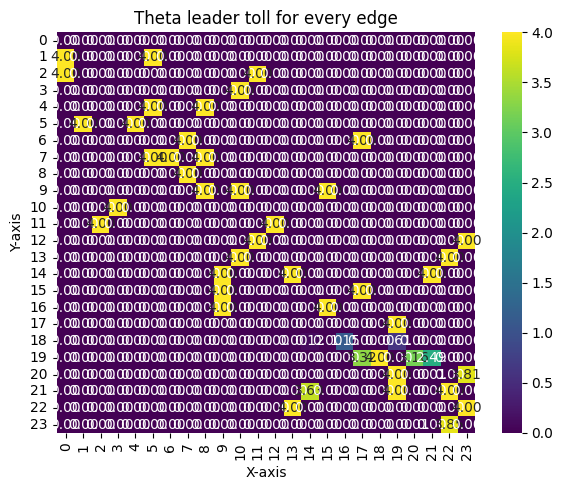

In [ ]:
plot_heatmap(theta_leader * env.A, title = "Theta leader toll for every edge")

In [ ]:
theta_leader * env.A

tensor([[0.0000e+00, 3.0539e-11, 2.2043e-10, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [4.9903e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.2193e-09,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [1.1721e-02, 0.0000e+00, 0.0000e+00, 1.7274e-08, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 2.8408e-06,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.00

In [ ]:
node_mass, edge_occ, final_flows, policies, W_cong_history, zeta_history = solve_multigroup(
    env, solvers, T=10, W_max=100, theta_leader=theta_leader,
    edge_cost=edge_cost, congest_all_edges=True
)

In [ ]:
edge_occ.sum(dim=0).sum(dim=-1)  # Total flow across all groups and time steps

tensor([[[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         ...,
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00]],

        [[0.0000e+00, 3.5513e-01, 6.4487e-01,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         ...,
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.000

In [ ]:
final_flows

tensor([[1.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        ...,
        [2.1616e-40, 2.5714e-41, 4.1446e-40,  ..., 1.0742e-40, 1.7483e-40,
         0.0000e+00],
        [2.2557e-40, 4.1073e-41, 3.6697e-40,  ..., 1.8736e-40, 1.1598e-40,
         0.0000e+00],
        [1.7565e-40, 6.9720e-41, 4.2725e-40,  ..., 2.7981e-40, 1.6432e-40,
         0.0000e+00]])

In [ ]:
exploitability, V_best, V_pi = solvers[0].compute_exploitability(W_cong_history, W_max=100, theta_leader=theta_leader)
exploitability

0.03656196594238281

In [ ]:
a = trainer.compute_social_loss(final_flows, W_cong_history)
a

tensor(23.2530)

In [ ]:
losses

[tensor(38.8385),
 tensor(38.6530),
 tensor(37.4700),
 tensor(35.0388),
 tensor(32.3468),
 tensor(30.4624),
 tensor(27.8537),
 tensor(27.2870),
 tensor(26.3177),
 tensor(25.7526),
 tensor(25.5095),
 tensor(24.9615),
 tensor(24.5273),
 tensor(24.1167),
 tensor(24.3559),
 tensor(24.3927),
 tensor(24.9551),
 tensor(23.3300),
 tensor(23.9232),
 tensor(23.5105),
 tensor(23.2151),
 tensor(23.2311),
 tensor(23.2638),
 tensor(23.2662),
 tensor(23.2641),
 tensor(23.2628),
 tensor(23.2622),
 tensor(23.2618),
 tensor(23.2616),
 tensor(23.2615),
 tensor(23.2615),
 tensor(23.2615),
 tensor(23.2615),
 tensor(23.2615),
 tensor(23.2615),
 tensor(23.2615),
 tensor(23.2615)]

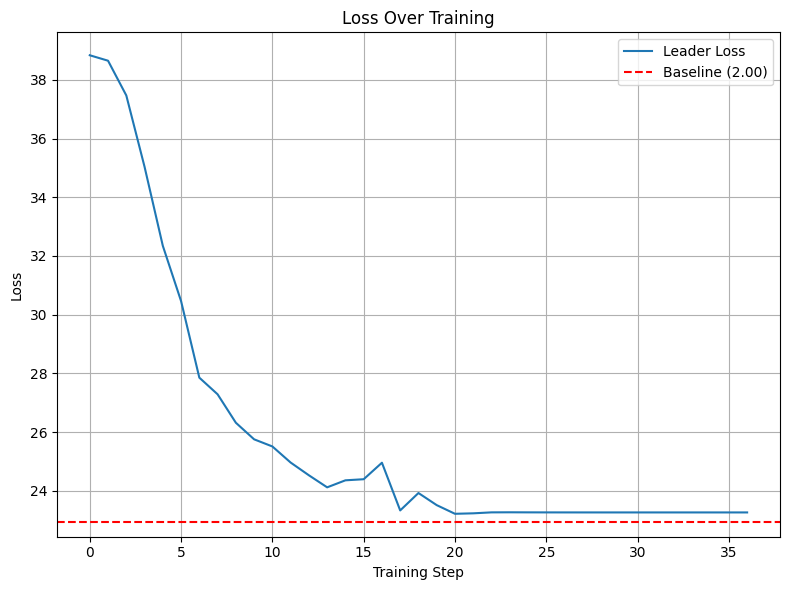

In [ ]:
import torch
# Convert the tensors to plain floats inside the dictionary
loss_dict = {
    "Leader Loss": [loss.item() for loss in losses]
}

# Now you can pass it safely to your plotting function
plot_losses_line(loss_dict, yline=22.945)

In [ ]:
import os
import numpy as np
import torch
import networkx as nx
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- 1. Extract environment variables from your notebook execution ---
num_nodes = env.num_nodes
nodes = [str(i) for i in range(num_nodes)]

# Pull physical roads defined in your environment's adjacency matrix
adjacency_matrix = env.A.cpu().numpy()
road_topology = []
for u_idx in range(num_nodes):
    for v_idx in range(num_nodes):
        if adjacency_matrix[u_idx, v_idx] > 0:
            road_topology.append((str(u_idx), str(v_idx)))

# --- 2. Node coordinates: works for ANY num_nodes, not just the original 4-node setup ---
# Tries to load the real, published Sioux Falls layout if you have the file locally;
# otherwise falls back to an automatic, deterministic graph layout via networkx.
node_coords = None
tntp_path = "SiouxFalls_node.tntp"  # adjust path if you've downloaded this file
if os.path.exists(tntp_path):
    node_coords = {}
    with open(tntp_path) as f:
        next(f)  # skip header line
        for line in f:
            line = line.strip().strip(';')
            if not line:
                continue
            parts = line.split()
            node_id, x, y = int(parts[0]), float(parts[1]), float(parts[2])
            node_coords[str(node_id - 1)] = (x, y)  # TNTP is 1-indexed, env is 0-indexed
    print(f"Loaded real node coordinates from {tntp_path}")

if node_coords is None:
    G = nx.DiGraph()
    G.add_nodes_from(range(num_nodes))
    for u_idx, v_idx in [(int(u), int(v)) for u, v in road_topology]:
        G.add_edge(u_idx, v_idx)

    # kamada_kawai spaces nodes by graph-theoretic distance and generally avoids
    # collisions much better than spring_layout's defaults, especially on graphs
    # this size (~24 nodes). Falls back to a heavily-tuned spring_layout if
    # kamada_kawai can't run (e.g. on a disconnected graph).
    try:
        pos = nx.kamada_kawai_layout(G)
    except Exception:
        pos = nx.spring_layout(
            G, seed=42,
            k=3.0 / np.sqrt(num_nodes),  # bigger k = more spacing between nodes
            iterations=200
        )

    # Scale up so the layout's real-world spread is large relative to the fixed
    # marker size (28px) -- otherwise nodes can visually overlap even when their
    # underlying coordinates are technically distinct.
    scale = 3.0
    node_coords = {str(i): (float(pos[i][0]) * scale, float(pos[i][1]) * scale) for i in range(num_nodes)}
    print(f"No {tntp_path} found -- using an auto-generated, collision-resistant layout instead.")

# --- 3. Compute the composite edge flows (H, N, N) from the model outputs ---
edge_flows_tensor = edge_occ.sum(dim=0).sum(dim=-1)  # (H, N, N)
E_total_edges = edge_flows_tensor.detach().cpu().numpy()

num_steps = E_total_edges.shape[0]
timesteps = [f"Horizon {h}" for h in range(num_steps)]
max_flow_value = float(np.max(E_total_edges)) if np.max(E_total_edges) > 0 else 1.0

# --- 4. Initialize the Subplot Figure ---
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "1. Origin-Destination Heatmap",
        "2. Physical Road Network (Thickness=Volume)"
    ),
    horizontal_spacing=0.1
)

# --- 5. Base Traces (Horizon 0) ---
z_init = E_total_edges[0]
heatmap_base = go.Heatmap(
    z=z_init, x=nodes, y=nodes,
    colorscale="Reds", zmin=0, zmax=max_flow_value,
    text=np.round(z_init, 3), texttemplate="%{text}",
    colorbar=dict(title="Flow Rate", len=0.45, y=0.5, x=0.45),
)
fig.add_trace(heatmap_base, row=1, col=1)

node_x = [node_coords[n][0] for n in nodes]
node_y = [node_coords[n][1] for n in nodes]
node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    text=nodes, textposition="top center",
    marker=dict(size=28, color='#333333', line=dict(width=2, color='white'))
)
fig.add_trace(node_trace, row=1, col=2)

for u, v in road_topology:
    x0, y0 = node_coords[u]
    x1, y1 = node_coords[v]
    u_idx, v_idx = int(u), int(v)
    flow = E_total_edges[0, u_idx, v_idx]

    width = 1.5 + (flow / max_flow_value) * 12
    color = '#D32F2F' if flow > (max_flow_value * 0.004) else '#E0E0E0'

    edge_trace = go.Scatter(
        x=[x0, x1, None], y=[y0, y1, None],
        mode='lines',
        line=dict(width=width, color=color),
        hoverinfo='text',
        text=f"Route: {u}→{v}<br>Flow: {flow:.3f}"
    )
    fig.add_trace(edge_trace, row=1, col=2)

# --- 6. Populate Frames ---
frames = []
for t in range(num_steps):
    frame_data = []

    z_frame = E_total_edges[t]
    frame_data.append(go.Heatmap(
        z=z_frame, text=np.round(z_frame, 3), texttemplate="%{text}"
    ))

    frame_data.append(node_trace)

    for u, v in road_topology:
        u_idx, v_idx = int(u), int(v)
        flow = E_total_edges[t, u_idx, v_idx]
        width = 1.5 + (flow / max_flow_value) * 12
        color = '#D32F2F' if flow > (max_flow_value * 0.05) else '#E0E0E0'

        frame_data.append(go.Scatter(
            line=dict(width=width, color=color),
            text=f"Route: {u}→{v}<br>Flow: {flow:.3f}"
        ))

    frames.append(go.Frame(data=frame_data, name=timesteps[t]))

fig.frames = frames

# --- 7. Add Layout & Slider Configurations ---
x_vals = [c[0] for c in node_coords.values()]
y_vals = [c[1] for c in node_coords.values()]
x_pad = (max(x_vals) - min(x_vals)) * 0.15 or 0.5
y_pad = (max(y_vals) - min(y_vals)) * 0.15 or 0.5

sliders = [{
    "active": 0,
    "currentvalue": {"prefix": "Time Step: ", "font": {"size": 14}},
    "pad": {"t": 50},
    "steps": [{
        "args": [[f_name], {"frame": {"duration": 600, "redraw": True}, "mode": "immediate"}],
        "label": f_name, "method": "animate"
    } for f_name in timesteps]
}]

fig.update_layout(
    title="Synchronized Mean Field Game Network Flow Dashboard",
    height=650,
    showlegend=False,
    xaxis2=dict(showgrid=False, zeroline=False, showticklabels=False,
                range=[min(x_vals) - x_pad, max(x_vals) + x_pad]),
    yaxis2=dict(showgrid=False, zeroline=False, showticklabels=False,
                range=[min(y_vals) - y_pad, max(y_vals) + y_pad],
                scaleanchor="x2", scaleratio=1),  # keep circles circular, not squished
    xaxis=dict(tickangle=0),
    updatemenus=[{
        "type": "buttons", "direction": "left", "pad": {"r": 10, "t": 87}, "showactive": False,
        "x": 0.1, "y": 0, "xanchor": "right", "yanchor": "top",
        "buttons": [
            {"label": "Play", "method": "animate", "args": [None, {"frame": {"duration": 800, "redraw": True}}]},
            {"label": "Pause", "method": "animate", "args": [[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}]}
        ]
    }],
    sliders=sliders
)

# Display interactive dashboard in the notebook
fig.show()
fig.write_html("traffic_flow_leader.html")


Loaded real node coordinates from SiouxFalls_node.tntp


In [ ]:
import pandas as pd

def get_total_trips_tntp(trips_file):
    total_trips = 0.0
    with open(trips_file, 'r') as f:
        for line in f:
            line = line.strip()
            # Skip metadata comments
            if line.startswith('<') or not line:
                continue
            if line.startswith('Origin'):
                continue
            
            # Parse pairs like "1 : 100.0; 2 : 200.0;"
            pairs = line.split(';')
            for pair in pairs:
                if ':' in pair:
                    dest, demand = pair.split(':')
                    total_trips += float(demand.strip())
                    
    return total_trips

# 1. Sum total trips
total_demand = get_total_trips_tntp("SiouxFalls_trips.tntp")
print(f"Total O-D Demand: {total_demand:.2f} trips") 
# (Note: For default Sioux Falls, total_demand is 360,600 trips)

# 2. Scale Capacities in the Network file
net_df = pd.read_csv("SiouxFalls_net.tntp", skiprows=8, sep='\t')
net_df.columns = net_df.columns.str.strip()

# Calculate scaling ratio relative to base demand
base_demand = 360600.0
scaling_factor = total_demand / base_demand

# Scale capacities down/up proportional to demand level
net_df['capacity'] = net_df['capacity'] * scaling_factor

Total O-D Demand: 360600.00 trips


In [ ]:
import pandas as pd

# 1. Load standard Sioux Falls network
net_df = pd.read_csv("SiouxFalls_net.tntp", skiprows=8, sep='\t')
net_df.columns = net_df.columns.str.strip()

# 2. Total driver demand in standard Sioux Falls network
total_drivers = 360600.0 

# 3. Create normalized capacity column for MFG (as a fraction/percentage)
net_df['mfg_capacity'] = net_df['capacity'] / total_drivers

# Inspect the normalized capacities
print(net_df[['init_node', 'term_node', 'capacity', 'mfg_capacity']].head())

   init_node  term_node      capacity  mfg_capacity
0          1          2  25900.200640      0.071825
1          1          3  23403.473190      0.064901
2          2          1  25900.200640      0.071825
3          2          6   4958.180928      0.013750
4          3          1  23403.473190      0.064901


In [ ]:
mfg_capacity = net_df['mfg_capacity'] 
mfg_capacity

0     0.071825
1     0.064901
2     0.071825
3     0.013750
4     0.064901
        ...   
71    0.013866
72    0.014083
73    0.014119
74    0.013548
75    0.014083
Name: mfg_capacity, Length: 76, dtype: float64

In [ ]:
print(mfg_capacity.to_string())

0     0.071825
1     0.064901
2     0.071825
3     0.013750
4     0.064901
5     0.047450
6     0.064901
7     0.047450
8     0.049314
9     0.013613
10    0.049314
11    0.013722
12    0.027732
13    0.013750
14    0.013722
15    0.013585
16    0.021747
17    0.064901
18    0.013585
19    0.021747
20    0.014005
21    0.013993
22    0.027732
23    0.014005
24    0.038591
25    0.038591
26    0.027732
27    0.037471
28    0.013463
29    0.013848
30    0.013613
31    0.027732
32    0.013613
33    0.013523
34    0.064901
35    0.013613
36    0.071825
37    0.071825
38    0.014119
39    0.013523
40    0.014219
41    0.013657
42    0.037471
43    0.014219
44    0.040390
45    0.026620
46    0.013993
47    0.013463
48    0.014503
49    0.054575
50    0.013848
51    0.014503
52    0.013378
53    0.064901
54    0.054575
55    0.064901
56    0.040390
57    0.013378
58    0.013873
59    0.064901
60    0.013873
61    0.014032
62    0.014076
63    0.014032
64    0.014503
65    0.013548
66    0.02

In [ ]:
capacity = torch.zeros((24, 24))

In [ ]:
capacity[0, 1] = 0.071825
capacity[0, 2] = 0.064901
capacity[1, 0] = 0.071825
capacity[1, 5] = 0.013750
capacity[2, 0] = 0.064901

capacity[2, 3] = 0.047450
capacity[2, 11] = 0.064901
capacity[3, 2] = 0.047450
capacity[3, 4] = 0.049314
capacity[3, 10] = 0.013613

capacity[4, 3] = 0.049314
capacity[4, 5] = 0.013722
capacity[4, 8] = 0.027732
capacity[5, 1] = 0.013750
capacity[5, 4] = 0.013722

capacity[5, 7] = 0.013585
capacity[6, 7] = 0.021747
capacity[6, 17] = 0.064901
capacity[7, 5] = 0.013585
capacity[7, 6] = 0.021747

capacity[7, 8] = 0.014005
capacity[7, 15] = 0.013993
capacity[8, 4] = 0.027732
capacity[8, 7] = 0.014005
capacity[8, 9] = 0.038591

capacity[9, 8] = 0.038591
capacity[9, 10] = 0.027732
capacity[9, 14] = 0.037471
capacity[9, 15] = 0.013463
capacity[9, 16] = 0.013848

capacity[10, 3] = 0.013613
capacity[10, 9] = 0.027732
capacity[10, 11] = 0.013613
capacity[10, 13] = 0.013523
capacity[11, 2] = 0.064901

capacity[11, 10] = 0.013613
capacity[11, 12] = 0.071825
capacity[12, 11] = 0.071825
capacity[12, 23] = 0.014119
capacity[13, 10] = 0.013523

capacity[13, 14] = 0.014219
capacity[13, 22] = 0.013657
capacity[14, 9] = 0.037471
capacity[14, 13] = 0.014219
capacity[14, 18] = 0.040390

capacity[14, 21] = 0.026620
capacity[15, 7] = 0.013993
capacity[15, 9] = 0.013463
capacity[15, 16] = 0.014503
capacity[15, 17] = 0.054575

capacity[16, 9] = 0.013848
capacity[16, 15] = 0.014503
capacity[16, 18] = 0.013378
capacity[17, 6] = 0.064901
capacity[17, 15] = 0.054575

capacity[17, 19] = 0.064901
capacity[18, 14] = 0.040390
capacity[18, 16] = 0.013378
capacity[18, 19] = 0.013873
capacity[19, 17] = 0.064901

capacity[19, 18] = 0.013873
capacity[19, 20] = 0.014032
capacity[20, 19] = 0.014032
capacity[20, 21] = 0.014503
capacity[20, 23] = 0.013548

capacity[21, 14] = 0.026620
capacity[21, 19] = 0.014076
capacity[21, 20] = 0.014503
capacity[21, 22] = 0.013866
capacity[22, 13] = 0.013657

capacity[22, 21] = 0.013866
capacity[22, 23] = 0.014083
capacity[23, 12] = 0.014119
capacity[23, 20] = 0.013548
capacity[23, 22] = 0.014083

capacity.sqrt_()

tensor([[0.0000, 0.2680, 0.2548, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2680, 0.0000, 0.0000, 0.0000, 0.0000, 0.1173, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2548, 0.0000, 0.0000, 0.2178, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.2548, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.2178, 0.0000, 0.2221, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.1167, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.2221, 0.0000, 0.1171, 0.0000, 0.0000, 0.1665,
         0.0000, 0.0000, 0.0000, 0.0000

In [ ]:
capacity[capacity != 0] 

tensor([0.2680, 0.2548, 0.2680, 0.1173, 0.2548, 0.2178, 0.2548, 0.2178, 0.2221,
        0.1167, 0.2221, 0.1171, 0.1665, 0.1173, 0.1171, 0.1166, 0.1475, 0.2548,
        0.1166, 0.1475, 0.1183, 0.1183, 0.1665, 0.1183, 0.1964, 0.1964, 0.1665,
        0.1936, 0.1160, 0.1177, 0.1167, 0.1665, 0.1167, 0.1163, 0.2548, 0.1167,
        0.2680, 0.2680, 0.1188, 0.1163, 0.1192, 0.1169, 0.1936, 0.1192, 0.2010,
        0.1632, 0.1183, 0.1160, 0.1204, 0.2336, 0.1177, 0.1204, 0.1157, 0.2548,
        0.2336, 0.2548, 0.2010, 0.1157, 0.1178, 0.2548, 0.1178, 0.1185, 0.1185,
        0.1204, 0.1164, 0.1632, 0.1186, 0.1204, 0.1178, 0.1169, 0.1178, 0.1187,
        0.1188, 0.1164, 0.1187])

In [ ]:
import torch

# Coordinates where values are non-zero (returns shape [N, 2] for 2D tensor)
indices = torch.nonzero(a)
print(indices)
# Example output:
# tensor([[ 0,  1],
#         [ 3, 12]])

tensor([[ 0,  1],
        [ 0,  2],
        [ 1,  0],
        [ 1,  5],
        [ 2,  0],
        [ 2,  3],
        [ 2, 11],
        [ 3,  2],
        [ 3,  4],
        [ 3, 10],
        [ 4,  3],
        [ 4,  5],
        [ 4,  8],
        [ 5,  1],
        [ 5,  4],
        [ 5,  7],
        [ 6,  7],
        [ 6, 17],
        [ 7,  5],
        [ 7,  6],
        [ 7,  8],
        [ 7, 15],
        [ 8,  4],
        [ 8,  7],
        [ 8,  9],
        [ 9,  8],
        [ 9, 10],
        [ 9, 14],
        [ 9, 15],
        [ 9, 16],
        [10,  3],
        [10,  9],
        [10, 11],
        [10, 13],
        [11,  2],
        [11, 10],
        [11, 12],
        [12, 11],
        [12, 23],
        [13, 10],
        [13, 14],
        [13, 22],
        [14,  9],
        [14, 13],
        [14, 18],
        [14, 21],
        [15,  7],
        [15,  9],
        [15, 16],
        [15, 17],
        [16,  9],
        [16, 15],
        [16, 18],
        [17,  6],
        [17, 15],
        [1

In [ ]:
a[19, 21]

tensor(1.)

In [ ]:
non_zero_count = (a != 0).sum().item()
non_zero_count

76

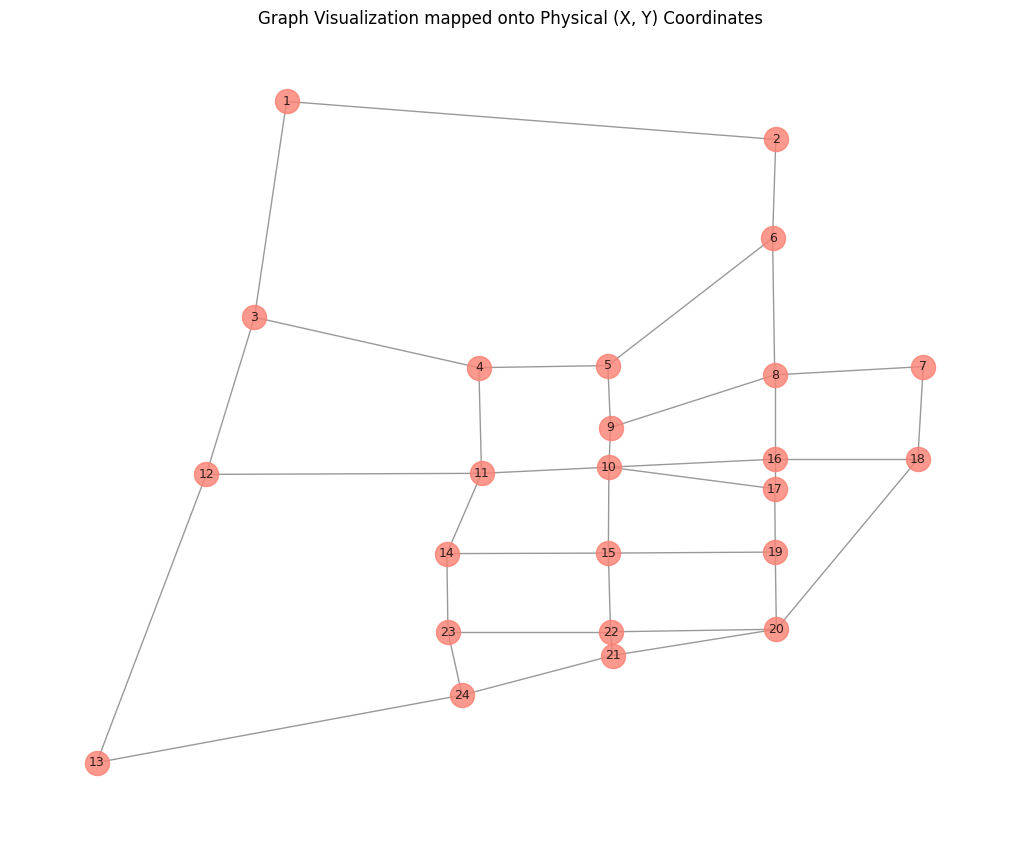

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import torch

# 1. Parse your node coordinates file (adjust delimiter if needed)
# Using io.StringIO for demonstration; replace with pd.read_csv('your_file.txt', sep='\t')
data = """Node	X	Y
1	-96.77041974	43.61282792
2	-96.71125063	43.60581298
3	-96.77430341	43.5729616
4	-96.74716843	43.56365362
5	-96.73156909	43.56403357
6	-96.71164389	43.58758553
7	-96.69342281	43.5638436
8	-96.71138171	43.56232379
9	-96.73124137	43.55259634
10	-96.73143801	43.54527088
11	-96.74684071	43.54413068
12	-96.78013678	43.54394065
13	-96.79337655	43.49070718
14	-96.75103549	43.52930613
15	-96.73150355	43.52940117
16	-96.71138171	43.54674361
17	-96.71138171	43.54128009
18	-96.69407825	43.54674361
19	-96.71131617	43.52959125
20	-96.71118508	43.5153335
21	-96.73097920	43.51048509
22	-96.73124137	43.51485818
23	-96.75090441	43.51485818
24	-96.74920028	43.50316422"""

import io
df = pd.read_csv(io.StringIO(data), sep='\t')

# 2. Extract positions dictionary matching 1-indexed node IDs
pos = {row['Node']: (row['X'], row['Y']) for _, row in df.iterrows()}

# 3. Convert env.A tensor to NetworkX Graph
adj_np = env.A.detach().cpu().numpy()
G = nx.from_numpy_array(adj_np)

# Relabel nodes to start from 1 to match your file's Node column
G = nx.relabel_nodes(G, lambda x: x + 1)

# 4. Plot using spatial coordinates
plt.figure(figsize=(10, 8))
nx.draw(
    G,
    pos=pos,               # Pass physical X, Y positions here!
    with_labels=True,
    node_color="salmon",
    node_size=300,
    font_size=9,
    edge_color="gray",
    alpha=0.8
)

plt.title("Graph Visualization mapped onto Physical (X, Y) Coordinates")
plt.xlabel("Longitude (X)")
plt.ylabel("Latitude (Y)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()